In [ ]:
!pip install vayuayan

In [ ]:
"""
Dehradun / Uttarakhand Air Quality Analysis
=============================================
Project #4 in Sahil Kumar's data analytics portfolio.

Data source: vayuayan (CPCB station data) — "Doon University, Dehradun" station.
Run this in Google Colab. Each `# %%` marks a natural cell break if you paste
sections into separate Colab cells.

Pipeline:
  1. Install & fetch data (2022-2024)
  2. Combine + clean + pivot to wide format
  3. Chart 1: Monthly trend
  4. Chart 2: Seasonal pattern
  5. Chart 3: Weekday vs weekend
  6. Chart 4: Pollutant comparison
  7. Chart 5: AQI category breakdown (CPCB breakpoints)
  8. Save all charts + a findings summary to disk
"""

# %% 1. Install & fetch data ---------------------------------------------
# !pip install vayuayan   # uncomment/run in Colab

import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
CITY = "Dehradun"
YEARS = [2022, 2023, 2024]
OUT_DIR = "outputs"
import os
os.makedirs(OUT_DIR, exist_ok=True)

def fetch_year(year):
    """Fetch one year of CPCB data via the vayuayan CLI and load it."""
    path = f"{CITY.lower()}_{year}.csv"
    subprocess.run(
        ["vayuayan", "city_data", "--city", CITY, "--year", str(year), "--path", path],
        check=True,
    )
    return pd.read_csv(path)

frames = [fetch_year(y) for y in YEARS]
raw = pd.concat(frames, ignore_index=True)
print(f"Fetched {len(raw):,} raw rows across {YEARS}")
print(raw.columns.tolist())

# %% 2. Clean & pivot to wide format --------------------------------------
# NOTE: exact column names depend on the vayuayan schema version — adjust
# the renames below after inspecting `raw.columns` / `raw.head()`.
# Typical CPCB long-format columns: ['date', 'station', 'pollutant_id', 'pollutant_avg']

raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
raw = raw.dropna(subset=["date"])

POLLUTANTS = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3"]

df = (
    raw[raw["pollutant_id"].isin(POLLUTANTS)]
    .pivot_table(
        index=["date", "station"],
        columns="pollutant_id",
        values="pollutant_avg",
        aggfunc="mean",
    )
    .reset_index()
)
df.columns.name = None

# Keep only the Dehradun station rows, coerce numeric, drop fully-empty rows
df = df[df["station"].str.contains("Dehradun", case=False, na=False)]
for p in POLLUTANTS:
    if p in df.columns:
        df[p] = pd.to_numeric(df[p], errors="coerce")

df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.strftime("%b")
df["year"] = df["date"].dt.year
df["weekday"] = df["date"].dt.day_name()
df["is_weekend"] = df["weekday"].isin(["Saturday", "Sunday"])

print(f"Cleaned dataset: {len(df):,} daily rows, {df['date'].min()} to {df['date'].max()}")
df.to_csv(f"{OUT_DIR}/dehradun_air_quality_clean.csv", index=False)

# %% 3. Chart 1 — Monthly trend -------------------------------------------
monthly = df.groupby(df["date"].dt.to_period("M"))[POLLUTANTS].mean()
monthly.index = monthly.index.to_timestamp()

plt.figure(figsize=(12, 6))
for p in POLLUTANTS:
    if p in monthly.columns:
        plt.plot(monthly.index, monthly[p], marker="o", label=p)
plt.title("Monthly Average Pollutant Levels — Dehradun (2022-2024)")
plt.xlabel("Month")
plt.ylabel("Concentration (µg/m³ or mg/m³)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/1_monthly_trend.png", dpi=150)
plt.close()

# %% 4. Chart 2 — Seasonal pattern -----------------------------------------
def month_to_season(m):
    if m in [12, 1, 2]:
        return "Winter"
    elif m in [3, 4, 5]:
        return "Summer"
    elif m in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

df["season"] = df["month"].apply(month_to_season)
seasonal = df.groupby("season")[POLLUTANTS].mean().reindex(
    ["Winter", "Summer", "Monsoon", "Post-Monsoon"]
)

seasonal.plot(kind="bar", figsize=(10, 6))
plt.title("Seasonal Average Pollutant Levels — Dehradun")
plt.ylabel("Concentration")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/2_seasonal_pattern.png", dpi=150)
plt.close()

# %% 5. Chart 3 — Weekday vs weekend ---------------------------------------
wk = df.groupby("is_weekend")[POLLUTANTS].mean()
wk.index = wk.index.map({True: "Weekend", False: "Weekday"})

wk.T.plot(kind="bar", figsize=(10, 6))
plt.title("Weekday vs Weekend Pollutant Levels — Dehradun")
plt.ylabel("Concentration")
plt.xlabel("Pollutant")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/3_weekday_vs_weekend.png", dpi=150)
plt.close()

# %% 6. Chart 4 — Pollutant comparison (which is worst) --------------------
avg_levels = df[POLLUTANTS].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=avg_levels.values, y=avg_levels.index, palette="rocket")
plt.title("Average Pollutant Levels — Dehradun (Overall)")
plt.xlabel("Average Concentration")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/4_pollutant_comparison.png", dpi=150)
plt.close()

# %% 7. Chart 5 — AQI category breakdown (CPCB breakpoints) ----------------
# CPCB National AQI sub-index breakpoints: (BP_lo, BP_hi, I_lo, I_hi)
BREAKPOINTS = {
    "PM2.5": [(0,30,0,50), (31,60,51,100), (61,90,101,200), (91,120,201,300), (121,250,301,400), (251,380,401,500)],
    "PM10":  [(0,50,0,50), (51,100,51,100), (101,250,101,200), (251,350,201,300), (351,430,301,400), (431,600,401,500)],
    "NO2":   [(0,40,0,50), (41,80,51,100), (81,180,101,200), (181,280,201,300), (281,400,301,400), (401,800,401,500)],
    "SO2":   [(0,40,0,50), (41,80,51,100), (81,380,101,200), (381,800,201,300), (801,1600,301,400), (1601,2100,401,500)],
    "CO":    [(0,1,0,50), (1.1,2,51,100), (2.1,10,101,200), (10.1,17,201,300), (17.1,34,301,400), (34.1,50,401,500)],
    "O3":    [(0,50,0,50), (51,100,51,100), (101,168,101,200), (169,208,201,300), (209,748,301,400), (749,1000,401,500)],
}

def sub_index(pollutant, conc):
    if pd.isna(conc):
        return np.nan
    for bp_lo, bp_hi, i_lo, i_hi in BREAKPOINTS[pollutant]:
        if bp_lo <= conc <= bp_hi:
            return ((i_hi - i_lo) / (bp_hi - bp_lo)) * (conc - bp_lo) + i_lo
    return 500  # above the top breakpoint, cap at 500

def aqi_category(aqi):
    if aqi <= 50: return "Good"
    if aqi <= 100: return "Satisfactory"
    if aqi <= 200: return "Moderate"
    if aqi <= 300: return "Poor"
    if aqi <= 400: return "Very Poor"
    return "Severe"

for p in POLLUTANTS:
    if p in df.columns:
        df[f"{p}_subindex"] = df[p].apply(lambda x: sub_index(p, x))

subindex_cols = [f"{p}_subindex" for p in POLLUTANTS if f"{p}_subindex" in df.columns]
df["AQI"] = df[subindex_cols].max(axis=1, skipna=True)
df["AQI_category"] = df["AQI"].apply(lambda x: aqi_category(x) if pd.notna(x) else np.nan)

cat_order = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]
cat_counts = df["AQI_category"].value_counts().reindex(cat_order).fillna(0)

plt.figure(figsize=(9, 6))
colors = ["#2ecc71", "#a3d977", "#f1c40f", "#e67e22", "#e74c3c", "#7d0d0d"]
plt.bar(cat_counts.index, cat_counts.values, color=colors)
plt.title("Days by AQI Category — Dehradun (2022-2024)")
plt.ylabel("Number of Days")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/5_aqi_category_breakdown.png", dpi=150)
plt.close()

# %% 8. Print a plain-language findings summary for the README -------------
worst_pollutant = avg_levels.index[0]
worst_season = seasonal.mean(axis=1).idxmax()
weekday_avg = wk.loc["Weekday"].mean()
weekend_avg = wk.loc["Weekend"].mean()

print("\n=== KEY FINDINGS (draft for README) ===")
print(f"- Data covers {df['date'].min().date()} to {df['date'].max().date()} "
      f"({len(df):,} station-days).")
print(f"- Worst-performing pollutant on average: {worst_pollutant} "
      f"({avg_levels.iloc[0]:.1f}).")
print(f"- Worst season for air quality: {worst_season}.")
print(f"- Weekday avg pollution ({weekday_avg:.1f}) vs weekend avg "
      f"({weekend_avg:.1f}) — {'higher' if weekday_avg > weekend_avg else 'lower'} "
      f"on weekdays.")
print(f"- AQI category breakdown (days): {cat_counts.to_dict()}")

FileNotFoundError: [Errno 2] No such file or directory: 'dehradun_2022.csv'

In [ ]:
!vayuayan city_data --city "Dehradun" --year 2022 --path "dehradun_2022.csv"


/bin/bash: line 1: vayuayan: command not found


In [ ]:
!pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 52.5 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0


Loaded 412 rows, 2020-01-03 to 2021-12-31
station
Clock Tower              140
Raipur Road              137
Himalayan Drug (ISBT)    135
Name: count, dtype: int64


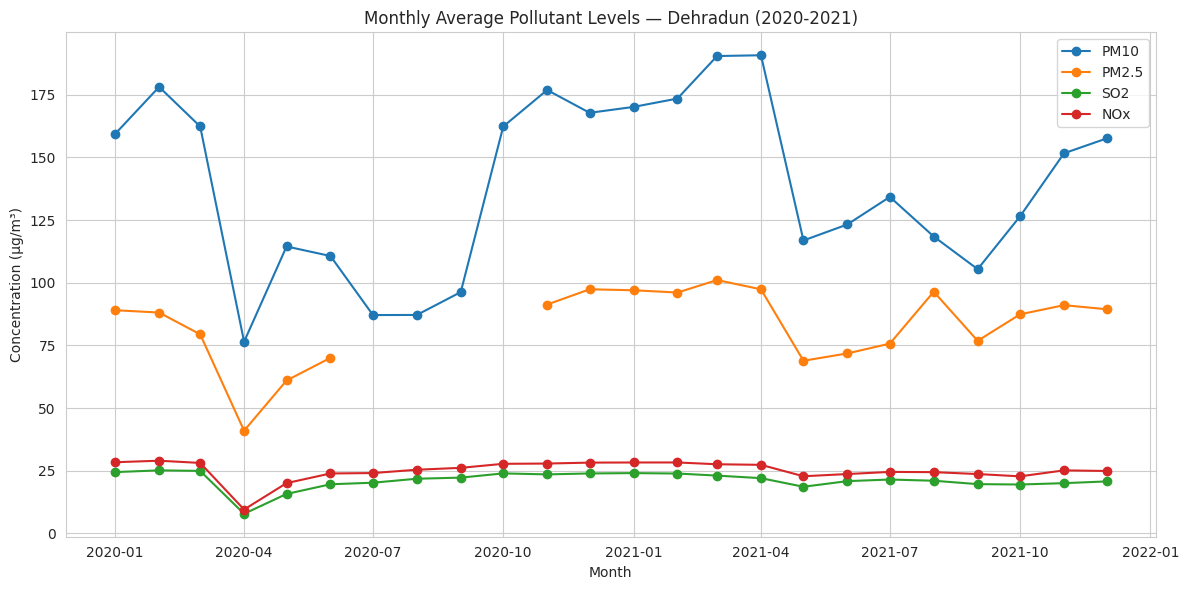

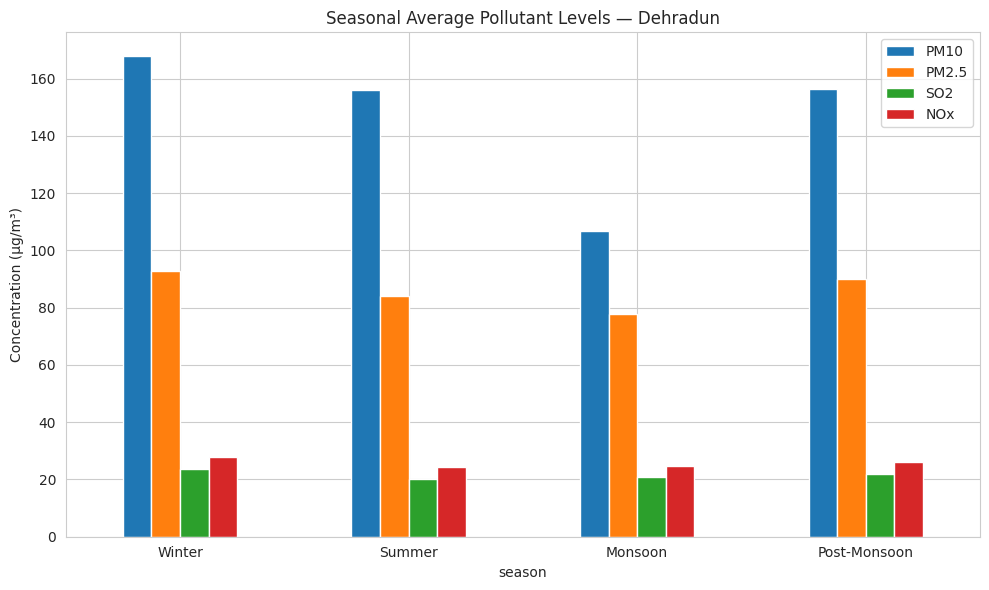

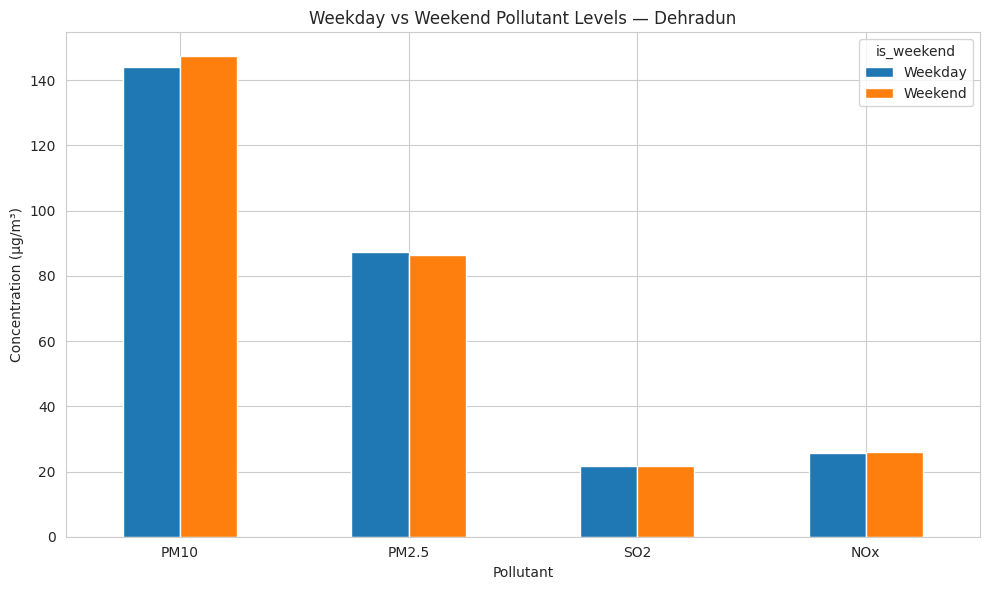

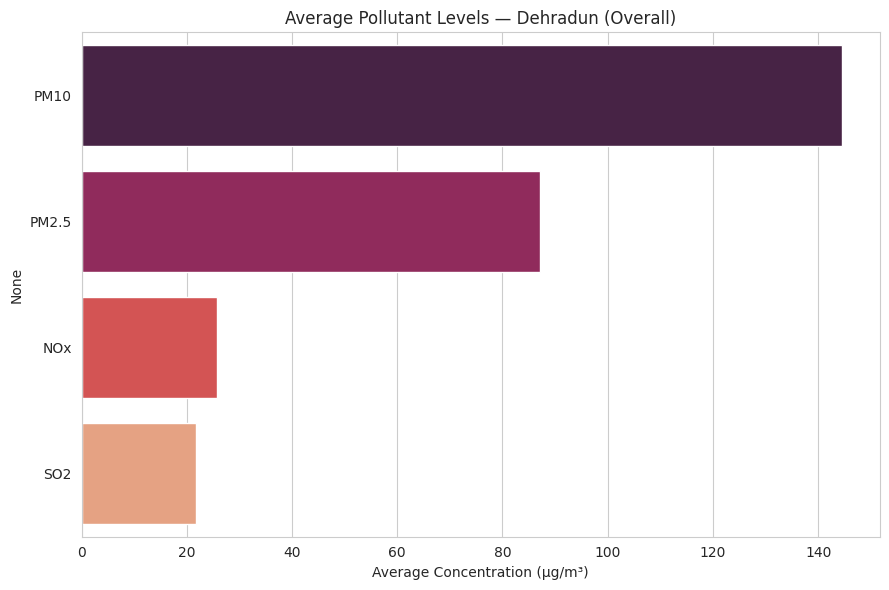

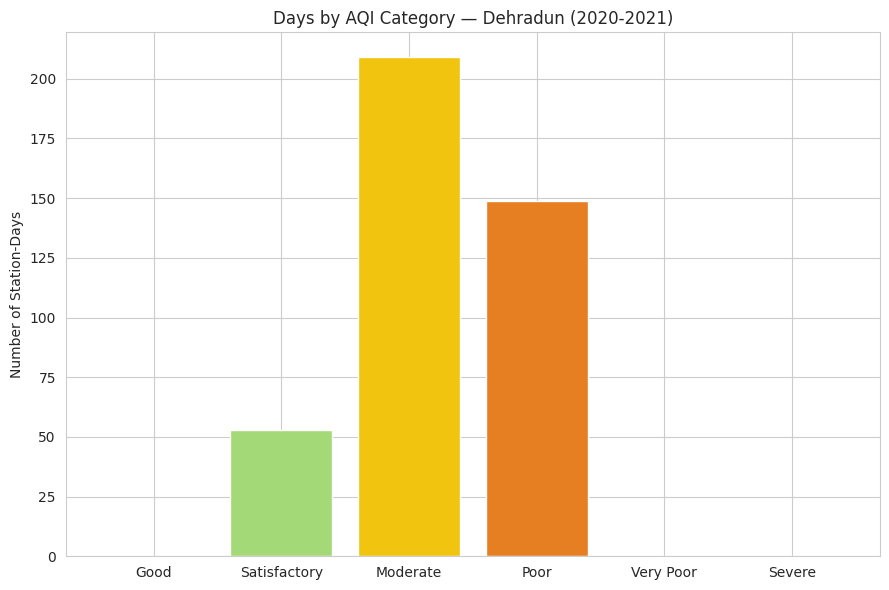


=== KEY FINDINGS (draft for README) ===
- Data covers 2020-01-03 to 2021-12-31 (412 station-days, 3 Dehradun stations).
- Worst-performing pollutant on average: PM10 (144.5 µg/m³).
- Worst season for air quality: Winter.
- Weekday avg pollution (69.8) vs weekend avg (70.4) — lower on weekdays.
- Station with worst average AQI: Himalayan Drug (ISBT) (avg AQI 192).
- AQI category breakdown (station-days): {'Good': 0.0, 'Satisfactory': 53.0, 'Moderate': 209.0, 'Poor': 149.0, 'Very Poor': 0.0, 'Severe': 0.0}

All charts + final CSV saved in the 'outputs/' folder.


In [ ]:
"""
Dehradun Air Quality Analysis (using uploaded dehradun_aqi_2020_2021.csv)
============================================================================
Data: 412 station-days, Jan 2020 - Dec 2021, 3 Dehradun stations
(Clock Tower, Raipur Road, Himalayan Drug ISBT), sourced from UKPCB PDF reports.

Run this in Colab AFTER uploading dehradun_aqi_2020_2021.csv (already done).
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# %% 1. Load data ----------------------------------------------------------
df = pd.read_csv("dehradun_aqi_2020_2021.csv", parse_dates=["date"])
POLLUTANTS = ["PM10", "PM2.5", "SO2", "NOx"]  # (no CO/O3 in this dataset)

print(f"Loaded {len(df)} rows, {df['date'].min().date()} to {df['date'].max().date()}")
print(df["station"].value_counts())

# %% 2. Chart 1 — Monthly trend --------------------------------------------
monthly = df.groupby(df["date"].dt.to_period("M"))[POLLUTANTS].mean()
monthly.index = monthly.index.to_timestamp()

plt.figure(figsize=(12, 6))
for p in POLLUTANTS:
    plt.plot(monthly.index, monthly[p], marker="o", label=p)
plt.title("Monthly Average Pollutant Levels — Dehradun (2020-2021)")
plt.xlabel("Month")
plt.ylabel("Concentration (µg/m³)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/1_monthly_trend.png", dpi=150)
plt.show()

# %% 3. Chart 2 — Seasonal pattern ------------------------------------------
def month_to_season(m):
    if m in [12, 1, 2]:
        return "Winter"
    elif m in [3, 4, 5]:
        return "Summer"
    elif m in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

df["season"] = df["month"].apply(month_to_season)
seasonal = df.groupby("season")[POLLUTANTS].mean().reindex(
    ["Winter", "Summer", "Monsoon", "Post-Monsoon"]
)

seasonal.plot(kind="bar", figsize=(10, 6))
plt.title("Seasonal Average Pollutant Levels — Dehradun")
plt.ylabel("Concentration (µg/m³)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/2_seasonal_pattern.png", dpi=150)
plt.show()

# %% 4. Chart 3 — Weekday vs weekend -----------------------------------------
wk = df.groupby("is_weekend")[POLLUTANTS].mean()
wk.index = wk.index.map({True: "Weekend", False: "Weekday"})

wk.T.plot(kind="bar", figsize=(10, 6))
plt.title("Weekday vs Weekend Pollutant Levels — Dehradun")
plt.ylabel("Concentration (µg/m³)")
plt.xlabel("Pollutant")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/3_weekday_vs_weekend.png", dpi=150)
plt.show()

# %% 5. Chart 4 — Pollutant comparison (which is worst) ----------------------
avg_levels = df[POLLUTANTS].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=avg_levels.values, y=avg_levels.index, hue=avg_levels.index,
            palette="rocket", legend=False)
plt.title("Average Pollutant Levels — Dehradun (Overall)")
plt.xlabel("Average Concentration (µg/m³)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/4_pollutant_comparison.png", dpi=150)
plt.show()

# %% 6. Chart 5 — AQI category breakdown -------------------------------------
def aqi_category(aqi):
    if pd.isna(aqi):
        return np.nan
    if aqi <= 50: return "Good"
    if aqi <= 100: return "Satisfactory"
    if aqi <= 200: return "Moderate"
    if aqi <= 300: return "Poor"
    if aqi <= 400: return "Very Poor"
    return "Severe"

df["AQI_category"] = df["AQI"].apply(aqi_category)
cat_order = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]
cat_counts = df["AQI_category"].value_counts().reindex(cat_order).fillna(0)

plt.figure(figsize=(9, 6))
colors = ["#2ecc71", "#a3d977", "#f1c40f", "#e67e22", "#e74c3c", "#7d0d0d"]
plt.bar(cat_counts.index, cat_counts.values, color=colors)
plt.title("Days by AQI Category — Dehradun (2020-2021)")
plt.ylabel("Number of Station-Days")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/5_aqi_category_breakdown.png", dpi=150)
plt.show()

# %% 7. Findings summary (for the README) ------------------------------------
worst_pollutant = avg_levels.index[0]
worst_season = seasonal.mean(axis=1).idxmax()
weekday_avg = wk.loc["Weekday"].mean()
weekend_avg = wk.loc["Weekend"].mean()
station_avg_aqi = df.groupby("station")["AQI"].mean().sort_values(ascending=False)

print("\n=== KEY FINDINGS (draft for README) ===")
print(f"- Data covers {df['date'].min().date()} to {df['date'].max().date()} "
      f"({len(df)} station-days, 3 Dehradun stations).")
print(f"- Worst-performing pollutant on average: {worst_pollutant} "
      f"({avg_levels.iloc[0]:.1f} µg/m³).")
print(f"- Worst season for air quality: {worst_season}.")
print(f"- Weekday avg pollution ({weekday_avg:.1f}) vs weekend avg "
      f"({weekend_avg:.1f}) — {'higher' if weekday_avg > weekend_avg else 'lower'} "
      f"on weekdays.")
print(f"- Station with worst average AQI: {station_avg_aqi.index[0]} "
      f"(avg AQI {station_avg_aqi.iloc[0]:.0f}).")
print(f"- AQI category breakdown (station-days): {cat_counts.to_dict()}")

df.to_csv(f"{OUT_DIR}/dehradun_final_with_categories.csv", index=False)
print(f"\nAll charts + final CSV saved in the '{OUT_DIR}/' folder.")

In [ ]:
 !zip -r outputs.zip outputs

  adding: outputs/ (stored 0%)
  adding: outputs/4_pollutant_comparison.png (deflated 25%)
  adding: outputs/dehradun_final_with_categories.csv (deflated 79%)
  adding: outputs/2_seasonal_pattern.png (deflated 23%)
  adding: outputs/5_aqi_category_breakdown.png (deflated 25%)
  adding: outputs/3_weekday_vs_weekend.png (deflated 23%)
  adding: outputs/1_monthly_trend.png (deflated 7%)
